# Лабораторная работа 4.1
## Анализ данных с помощью Dask и визуализация графов (DAG)

**Вариант:** 01  
**Датасет:** Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv

### Цель работы
Получить практические навыки работы с библиотекой Dask для построения ETL-конвейера (Extract, Transform, Load) при обработке больших массивов данных, а также изучить принципы ленивых вычислений и визуализацию DAG.

In [ ]:
!pip install "dask[complete]" graphviz pyarrow
!apt-get install -y graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


In [ ]:
import dask
import dask.dataframe as dd
import dask.delayed as delayed
from dask.distributed import Client
from dask.diagnostics import ProgressBar

In [ ]:
!ls -lh /content

total 16M
-rw-r--r-- 1 root root  15M Mar 30 07:41 Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv
drwxr-xr-x 1 root root 4.0K Mar 23 13:29 sample_data


In [ ]:
client = Client(n_workers=2, threads_per_worker=2, processes=True)
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:33213
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44463'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46881'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:33059 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:33059
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:58616
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:39657 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:39657
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33213,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39657,Total threads: 2
Dashboard: http://127.0.0.1:41401/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:44463,


## 1. Extract — ленивое чтение датасета

На этом этапе выполняется подключение к большому CSV-файлу с помощью Dask.  
Данные не загружаются в оперативную память полностью: Dask только строит план вычислений и разбивает файл на части (partitions).

In [ ]:
file_path = "/content/Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv"

df = dd.read_csv(file_path, assume_missing=True)
df

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,float64,string,string,string,string,float64,string,string,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,string,float64,string,string,float64,string,string,float64,float64,string,float64,string,string,string,string,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


При чтении датасета возникла проблема автоматического определения типов данных.  
Некоторые столбцы содержат смешанные значения (числа, текст, коды), поэтому для них тип был задан вручную как `object`.  
После этого датасет был успешно загружен средствами Dask.

In [ ]:
file_path = "/content/Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv"

dtype_dict = {
    'House Number': 'object',
    'Issuer Command': 'object',
    'Issuer Squad': 'object',
    'Time First Observed': 'object',
    'Violation Description': 'object',
    'Violation Legal Code': 'object',
    'Violation Post Code': 'object'
}

df = dd.read_csv(file_path, dtype=dtype_dict, assume_missing=True)
df

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
npartitions=2,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,float64,string,string,string,string,float64,string,string,string,float64,float64,float64,float64,float64,float64,float64,float64,string,string,string,string,string,string,string,string,string,float64,float64,string,string,string,string,string,string,float64,float64,string,float64,string,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [ ]:
print("Количество partitions:", df.npartitions)
df.head()

Количество partitions: 2


,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Hydrant Violation,Double Parking Violation,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
0,1.283294e+09,GBB9093,NY,PAS,08/04/2013,46.0,SUBN,AUDI,P,37250.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.283294e+09,62416MB,NY,COM,08/04/2013,46.0,VAN,FORD,P,37290.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.283294e+09,78755JZ,NY,COM,08/05/2013,46.0,P-U,CHEVR,P,37030.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.283294e+09,63009MA,NY,COM,08/05/2013,46.0,VAN,FORD,P,37270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.283294e+09,91648MC,NY,COM,08/08/2013,41.0,TRLR,GMC,P,37240.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Датасет был дополнительно переразбит на 4 части с помощью `repartition()`.  
Это позволяет лучше продемонстрировать обработку данных по частям.

In [ ]:
df = df.repartition(npartitions=4)
print("Количество partitions после repartition:", df.npartitions)

Количество partitions после repartition: 4


## 2. Transform — анализ пропущенных значений

На этом этапе выполняется профилирование качества данных.  
С помощью Dask рассчитывается процент пропущенных значений по каждому столбцу.  
Вычисления выполняются лениво, а `.compute()` используется только для получения итоговой компактной статистики.

In [ ]:
missing_values = df.isnull().sum()
mysize = df.index.size
missing_count = (missing_values / mysize) * 100

In [ ]:
with ProgressBar():
    missing_count_percent = missing_count.compute()

In [ ]:
print(missing_count_percent)

Summons Number                         0.000000
Plate ID                               0.054904
Registration State                     0.000000
Plate Type                             0.000000
Issue Date                             0.000000
Violation Code                         0.000000
Vehicle Body Type                      1.988457
Vehicle Make                           0.939104
Issuing Agency                         0.000000
Street Code1                           0.000000
Street Code2                           0.000000
Street Code3                           0.000000
Vehicle Expiration Date                0.000000
Violation Location                     9.294480
Violation Precinct                     0.000000
Issuer Precinct                        0.000000
Issuer Code                            0.000000
Issuer Command                         9.046162
Issuer Squad                           9.046162
Violation Time                         0.037240
Time First Observed                   89

In [ ]:
missing_count_percent = missing_count_percent.sort_values(ascending=False)
print(missing_count_percent)

Community Board                      100.000000
Longitude                            100.000000
Latitude                             100.000000
BBL                                  100.000000
BIN                                  100.000000
NTA                                  100.000000
Census Tract                         100.000000
Community Council                    100.000000
Hydrant Violation                    100.000000
No Standing or Stopping Violation    100.000000
Double Parking Violation             100.000000
Violation Legal Code                  90.916598
Time First Observed                   89.531052
Unregistered Vehicle?                 82.272131
Intersecting Street                   77.715122
Meter Number                          74.189213
From Hours In Effect                  36.011104
To Hours In Effect                    36.011104
Violation Post Code                   26.736790
Violation Description                 17.727869
Days Parking In Effect                16

In [ ]:
columns_to_drop = list(missing_count_percent[missing_count_percent > 60].index)
print("Удаляемые столбцы:", columns_to_drop)

Удаляемые столбцы: ['Community Board', 'Longitude', 'Latitude', 'BBL', 'BIN', 'NTA', 'Census Tract', 'Community Council ', 'Hydrant Violation', 'No Standing or Stopping Violation', 'Double Parking Violation', 'Violation Legal Code', 'Time First Observed', 'Unregistered Vehicle?', 'Intersecting Street', 'Meter Number']


In [ ]:
print("Количество столбцов для удаления:", len(columns_to_drop))

Количество столбцов для удаления: 16


По результатам анализа были определены столбцы, в которых доля пропущенных значений превышает 60%.  
Такие столбцы считаются слишком разреженными, поэтому их целесообразно удалить на этапе очистки данных.

In [ ]:
df_dropped = df.drop(columns=columns_to_drop)

Здесь:

* данные НЕ пересчитываются;
* НЕ загружаются в память;
* Dask просто записывает: "эти столбцы больше не нужны".

Это и есть ленивая трансформация.

In [ ]:
df_dropped.head()

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
0,1.283294e+09,GBB9093,NY,PAS,08/04/2013,46.0,SUBN,AUDI,P,37250.0,...,408.0,F1,BBBBBBB,ALL,ALL,GY,2013.0,0.0,<NA>,<NA>
1,1.283294e+09,62416MB,NY,COM,08/04/2013,46.0,VAN,FORD,P,37290.0,...,408.0,C,BBBBBBB,ALL,ALL,WH,2012.0,0.0,<NA>,<NA>
2,1.283294e+09,78755JZ,NY,COM,08/05/2013,46.0,P-U,CHEVR,P,37030.0,...,408.0,F7,BBBBBBB,ALL,ALL,<NA>,0.0,0.0,<NA>,<NA>
3,1.283294e+09,63009MA,NY,COM,08/05/2013,46.0,VAN,FORD,P,37270.0,...,408.0,F1,BBBBBBB,ALL,ALL,WH,2010.0,0.0,<NA>,<NA>
4,1.283294e+09,91648MC,NY,COM,08/08/2013,41.0,TRLR,GMC,P,37240.0,...,408.0,E1,BBBBBBB,ALL,ALL,BR,2012.0,0.0,<NA>,<NA>


In [ ]:
print("До очистки:", len(df.columns))
print("После очистки:", len(df_dropped.columns))

До очистки: 51
После очистки: 35


Удаление столбцов было выполнено лениво с помощью метода `.drop()`.  
На этом этапе данные не пересчитываются и не загружаются в память.  
Dask лишь обновляет граф вычислений, исключая указанные столбцы из дальнейшей обработки.

In [ ]:
df_dropped.to_parquet('cleaned_dataset.parquet', engine='pyarrow')

In [ ]:
!ls -lh

total 425M
drwxr-xr-x 2 root root 4.0K Mar 30 07:54 cleaned_dataset.parquet
-rw-r--r-- 1 root root 424M Mar 30 07:54 Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv
drwxr-xr-x 1 root root 4.0K Mar 23 13:29 sample_data


Очищенный датасет был сохранен в формате Parquet.  
Данный формат позволяет эффективно хранить большие объемы данных и обеспечивает высокую скорость чтения и записи.  
Dask сохраняет данные по частям, что позволяет избежать переполнения оперативной памяти.

## 3. Визуализация DAG (Directed Acyclic Graph)

Dask строит граф вычислений (DAG), в котором каждая операция является узлом, а зависимости между операциями — ребрами.  
На этом этапе будут рассмотрены примеры простого и сложного графа вычислений.

In [ ]:
def increment(i):
    return i + 1

def add(x, y):
    return x + y

In [ ]:
x = delayed(increment)(1)
y = delayed(increment)(2)
z = delayed(add)(x, y)

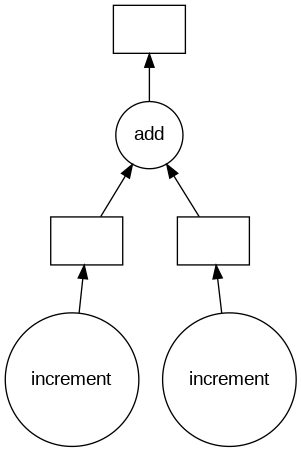

In [ ]:
z.visualize()

In [ ]:
print("Результат DAG:", z.compute())

Результат DAG: 5


В данном графе сначала выполняются две независимые операции increment, после чего их результаты передаются в функцию add.  
Таким образом, Dask сначала строит граф зависимостей, а затем выполняет вычисления.

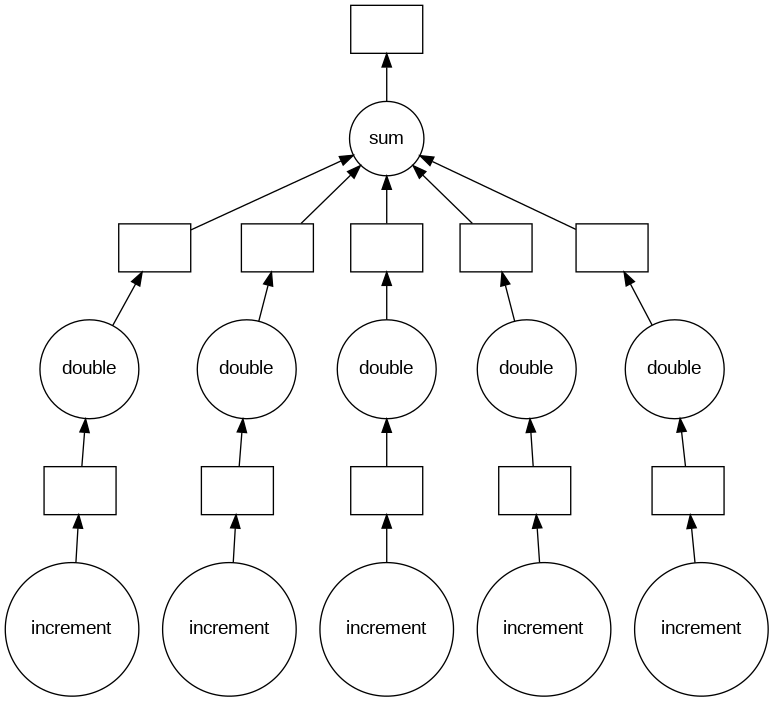

In [ ]:
data = [1, 2, 3, 4, 5]
layer1 = [delayed(increment)(i) for i in data]
def double(x):
    return x * 2

layer2 = [delayed(double)(j) for j in layer1]
total2 = delayed(sum)(layer2)
total2.visualize()

In [ ]:
result = total2.compute()
print("Итоговый результат:", result)

Итоговый результат: 40


Данный граф состоит из нескольких уровней.  
На первом уровне каждый элемент списка увеличивается на 1.  
На втором уровне результаты умножаются на 2.  
После этого выполняется агрегирующая операция суммирования.  

Такая структура напоминает модель map-reduce, используемую при обработке больших данных.

Дополнительно был визуализирован граф вычислений для расчета пропущенных значений.  
Граф демонстрирует, как Dask разбивает задачу на подзадачи и формирует зависимости между ними.

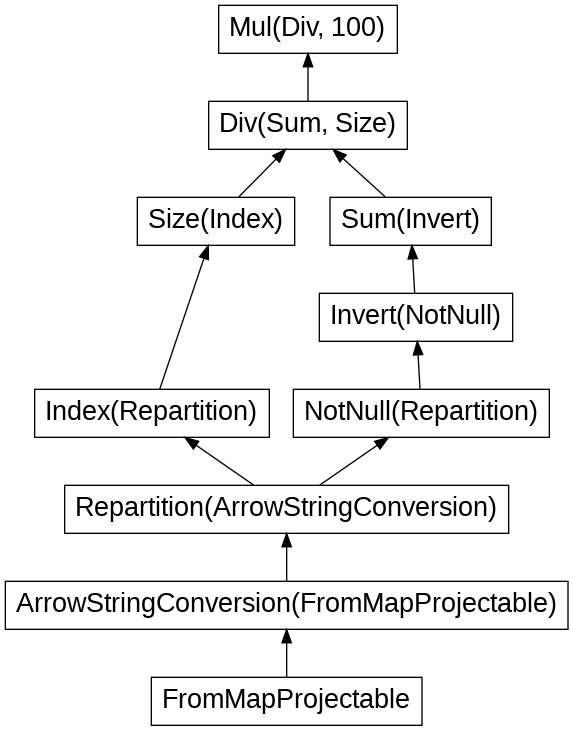

In [ ]:
from IPython.display import Image

missing_count.visualize(filename="missing_dag", format="png")

Image("missing_dag.png")

## 4. Анализ датасета

### Топ нарушений

In [ ]:
violation_counts = df_dropped['Violation Code'].value_counts().nlargest(10)

with ProgressBar():
    violation_counts = violation_counts.compute()

violation_counts

,count
Violation Code,
21.0,99708
38.0,84615
14.0,61662
37.0,50022
7.0,46206
71.0,37810
20.0,37544
46.0,37521
40.0,31063


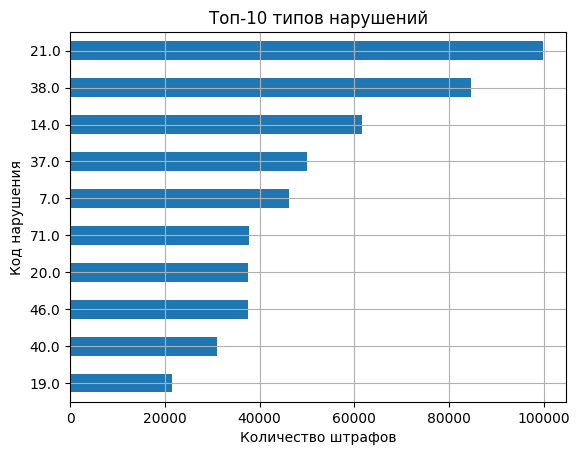

In [ ]:
import matplotlib.pyplot as plt

violation_counts.sort_values().plot(kind='barh')

plt.title("Топ-10 типов нарушений")
plt.xlabel("Количество штрафов")
plt.ylabel("Код нарушения")
plt.grid()

plt.show()

Был проведен анализ наиболее распространенных типов нарушений.  
На графике представлены 10 наиболее часто встречающихся кодов нарушений.

Это позволяет определить, какие виды нарушений наиболее характерны для данного периода.

### Марки автомобилей

In [ ]:
top_makes = df_dropped['Vehicle Make'].value_counts().nlargest(10)

with ProgressBar():
    top_makes = top_makes.compute()

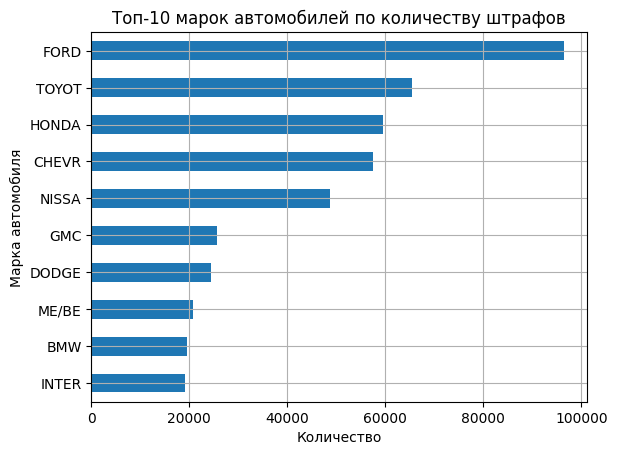

In [ ]:
top_makes.sort_values().plot(kind='barh')

plt.title("Топ-10 марок автомобилей по количеству штрафов")
plt.xlabel("Количество")
plt.ylabel("Марка автомобиля")
plt.grid()

plt.show()

Проанализированы наиболее часто встречающиеся марки автомобилей среди нарушителей.  
Это позволяет определить, какие автомобили чаще всего участвуют в нарушениях.

### Цвет автомобилей

In [ ]:
top_colors = df_dropped['Vehicle Color'].value_counts().nlargest(10)

with ProgressBar():
    top_colors = top_colors.compute()

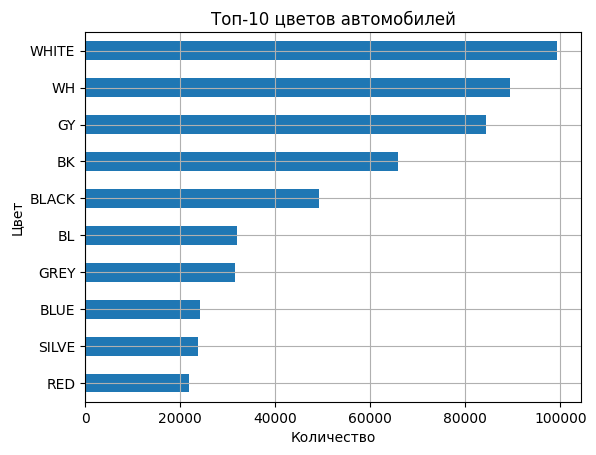

In [ ]:
top_colors.sort_values().plot(kind='barh')

plt.title("Топ-10 цветов автомобилей")
plt.xlabel("Количество")
plt.ylabel("Цвет")
plt.grid()

plt.show()

### Год автомобиля

In [ ]:
vehicle_year = df_dropped['Vehicle Year']

vehicle_year = vehicle_year[vehicle_year > 0]

year_counts = vehicle_year.value_counts().nlargest(15)

with ProgressBar():
    year_counts = year_counts.compute()

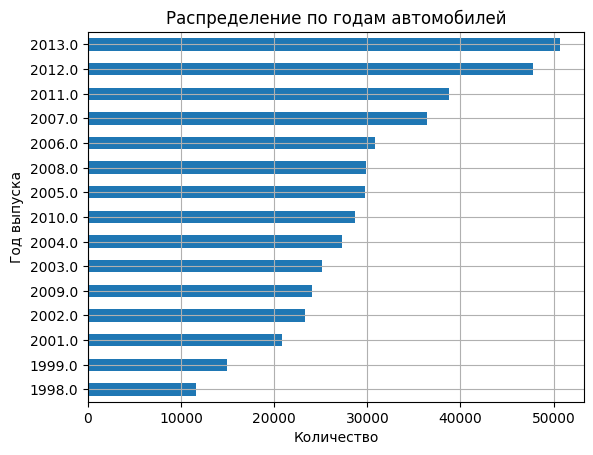

In [ ]:
year_counts.sort_values().plot(kind='barh')

plt.title("Распределение по годам автомобилей")
plt.xlabel("Количество")
plt.ylabel("Год выпуска")
plt.grid()

plt.show()

### Анализ по датам

In [ ]:
df_dropped['Issue Date'] = dd.to_datetime(df_dropped['Issue Date'], errors='coerce')

date_counts = df_dropped['Issue Date'].dt.month.value_counts().compute().sort_index()

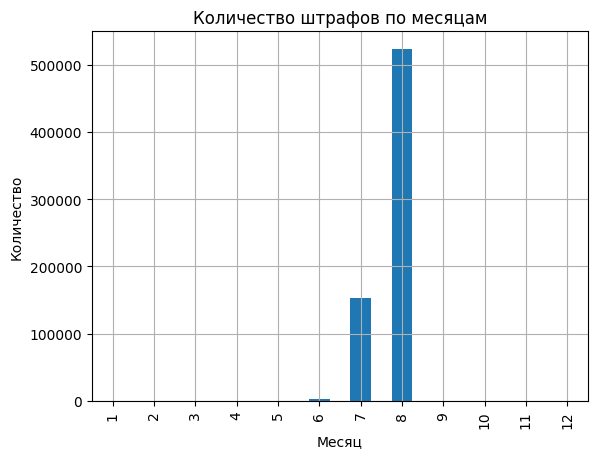

In [ ]:
date_counts.plot(kind='bar')

plt.title("Количество штрафов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество")
plt.grid()

plt.show()

По представленному графику видно, что распределение штрафов по месяцам имеет ярко выраженную неравномерность.

Основное количество штрафов приходится на июль и особенно август, где наблюдается максимальное значение. В июне количество штрафов значительно ниже, а в остальные месяцы данные практически отсутствуют.

Это объясняется тем, что рассматриваемый датасет охватывает период с августа 2013 года по июнь 2014 года, однако фактически данные в выборке сосредоточены преимущественно в летние месяцы.

Таким образом, пик нарушений приходится на летний период, что может быть связано с увеличением транспортной активности, сезонными факторами или особенностями сбора данных.





### 1. Главное отличие Dask и Pandas

`pandas.DataFrame` обрабатывает данные в памяти одной машины и выполняет операции сразу.
`dask.dataframe` разбивает данные на партиции, использует параллельные и ленивые вычисления, что позволяет работать с данными, не помещающимися в RAM.



### 2. Что такое lazy evaluation и зачем откладывать `.compute()`

Ленивые вычисления — это подход, при котором операции не выполняются сразу, а только строится план их выполнения.

Метод `.compute()` запускает реальные вычисления, поэтому его следует вызывать в конце ETL-пайплайна, чтобы:

* оптимизировать выполнение (объединить операции);
* уменьшить количество проходов по данным;
* снизить нагрузку на ресурсы.



### 3. Что такое DAG в Dask и его роль

DAG (Directed Acyclic Graph) — это ориентированный ациклический граф, где:

* узлы — операции,
* рёбра — зависимости между ними.

В Dask DAG формируется автоматически при построении цепочки операций.
Он используется планировщиком для:

* оптимизации вычислений;
* параллельного выполнения задач;
* устранения лишних операций.





## Общий вывод

В ходе выполнения лабораторной работы был изучен процесс построения ETL-конвейера с использованием библиотеки Dask для обработки больших объемов данных.

На этапе Extract была выполнена ленивое чтение исходного CSV-файла без полной загрузки данных в оперативную память, что позволило эффективно работать с крупным датасетом. Был настроен локальный кластер Dask, обеспечивающий параллельную обработку данных.

На этапе Transform проведен анализ качества данных: вычислены проценты пропущенных значений, выявлены разреженные столбцы, после чего выполнено их удаление с использованием ленивых операций. Это позволило оптимизировать структуру датасета без перегрузки памяти.

На этапе Load очищенные данные были сохранены в формате Parquet, что обеспечивает эффективное хранение и дальнейшую обработку данных.

Дополнительно были построены и визуализированы графы вычислений (DAG), демонстрирующие принцип ленивых вычислений и зависимости между задачами в Dask.

В рамках аналитической части были исследованы основные характеристики датасета: выявлены наиболее распространенные типы нарушений, популярные марки и цвета автомобилей, а также распределение штрафов по времени. Анализ показал наличие выраженных закономерностей, в частности сезонность нарушений и концентрацию данных в определенные периоды.

Таким образом, в работе продемонстрированы возможности Dask для обработки больших данных, а также получены практические навыки построения ETL-процессов и анализа данных.